In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
import os
print("Current Folder:")
print(os.getcwd())
print("\nFiles:")
for file in os.listdir():
    print(file)    

Current Folder:
c:\Users\MY PC\OneDrive\Desktop\bluestock_mf_capstone\notebooks

Files:
EDA_Analysis.ipynb
Performance_analytics.ipynb


In [3]:
import os
parent_folder=".."
print("files in project folder:\n")
for file in os.listdir(parent_folder):
    print(file)

files in project folder:

.git
.gitignore
dashboard
data
notebooks
reports
requirements.txt
scripts
sql
testenv
venv


In [4]:
import os
print("files in datafolder:\n")
for file in os.listdir("../data"):
    print(file)

files in datafolder:

db
processed
raw


In [6]:
import os
print("files in processed folder:\n")
for file in os.listdir("../data/processed"):
    print(file)

files in processed folder:

investor_transactions_cleaned.csv
nav_history_cleaned.csv
scheme_performance_cleaned.csv


In [8]:
nav_df=pd.read_csv("../data/processed/nav_history_cleaned.csv")
print(nav_df.head())
print("\ncolumns:")
print(nav_df.columns)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [9]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])
print(nav_df.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [10]:
nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [11]:
nav_df[['amfi_code',
        'date',
        'nav',
        'daily_return']].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [12]:
nav_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

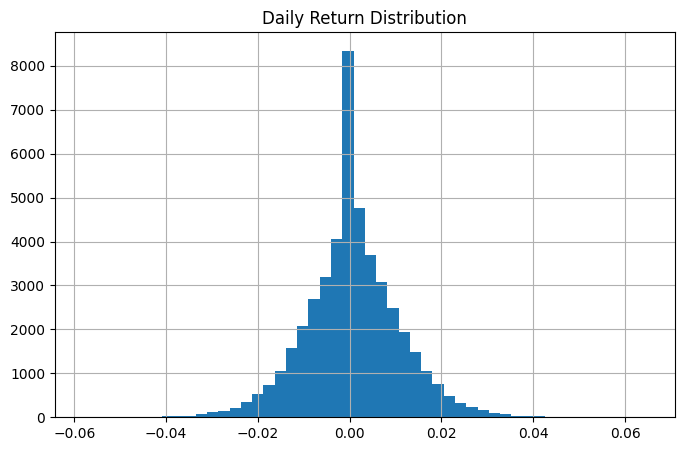

In [13]:
plt.figure(figsize=(8,5))

nav_df['daily_return'].dropna().hist(
    bins=50
)

plt.title('Daily Return Distribution')
plt.show()

In [14]:
print(nav_df['date'].min())
print(nav_df['date'].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [16]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [17]:
cagr_results = []

for code in nav_df['amfi_code'].unique():

    fund = nav_df[nav_df['amfi_code'] == code]

    start_nav = fund['nav'].iloc[0]
    end_nav = fund['nav'].iloc[-1]

    years = (
        (fund['date'].max() -
         fund['date'].min()).days
    ) / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code', 'CAGR']
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [18]:
cagr_df = cagr_df.sort_values(
    'CAGR',
    ascending=False
)

cagr_df.head(10)

,amfi_code,CAGR
25,120505,0.328016
21,119598,0.323981
39,149324,0.322621
36,148569,0.319245
34,148567,0.309499
30,120843,0.308833
2,100033,0.300997
38,149323,0.295581
16,119094,0.281926
19,119551,0.257849


In [19]:
rf=0.065

In [20]:
def sharpe_ratio(returns):

    annual_return = returns.mean() * 252

    annual_std = returns.std() * np.sqrt(252)

    if annual_std == 0:
        return np.nan

    return (annual_return - rf) / annual_std

In [21]:
sharpe_results = []

for code in nav_df['amfi_code'].unique():

    returns = nav_df[
        nav_df['amfi_code'] == code
    ]['daily_return'].dropna()

    sharpe = sharpe_ratio(returns)

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code', 'Sharpe_Ratio']
)

sharpe_df = sharpe_df.sort_values(
    'Sharpe_Ratio',
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [23]:
print(sharpe_df.describe())

           amfi_code  Sharpe_Ratio
count      40.000000     40.000000
mean   120247.000000      0.537220
std     14534.998667      0.573689
min    100016.000000     -0.815567
25%    118632.750000      0.064696
50%    119551.500000      0.647043
75%    120842.250000      1.005304
max    149324.000000      1.448291


In [24]:
sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [25]:
def sortino_ratio(returns):

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std == 0:
        return np.nan

    return (annual_return - rf) / downside_std

In [26]:
sortino_results = []

for code in nav_df['amfi_code'].unique():

    returns = nav_df[
        nav_df['amfi_code'] == code
    ]['daily_return'].dropna()

    sortino = sortino_ratio(returns)

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=['amfi_code', 'Sortino_Ratio']
)

sortino_df = sortino_df.sort_values(
    'Sortino_Ratio',
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [27]:
sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [28]:
sortino_df.describe()

,amfi_code,Sortino_Ratio
count,40.000000,40.000000
mean,120247.000000,0.923338
std,14534.998667,1.005410
min,100016.000000,-1.681038
25%,118632.750000,0.106664
50%,119551.500000,1.116936
75%,120842.250000,1.727739
max,149324.000000,2.385644


In [29]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        if "nifty" in file.lower():
            print(os.path.join(root, file))

In [30]:
for root, dirs, files in os.walk("../data"):
    for file in files:
        print(os.path.join(root, file))

../data\db\bluestock_mf.db
../data\processed\investor_transactions_cleaned.csv
../data\processed\nav_history_cleaned.csv
../data\processed\scheme_performance_cleaned.csv
../data\raw\01_fund_master.csv
../data\raw\02_nav_history.csv
../data\raw\03_aum_by_fund_house.csv
../data\raw\04_monthly_sip_inflows.csv
../data\raw\05_category_inflows.csv
../data\raw\06_industry_folio_count.csv
../data\raw\07_scheme_performance.csv
../data\raw\08_investor_transactions.csv
../data\raw\09_portfolio_holdings.csv
../data\raw\10_benchmark_indices.csv
../data\raw\118632_nav.csv
../data\raw\119092_nav.csv
../data\raw\119551_nav.csv
../data\raw\120503_nav.csv
../data\raw\120841_nav.csv
../data\raw\125497_nav.csv


In [31]:
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark_df.head())
print("\nColumns:")
print(benchmark_df.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='object')


In [32]:
['date', 'index_name', 'close_value']

['date', 'index_name', 'close_value']

In [33]:
benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [34]:
benchmark_df['date'] = pd.to_datetime(
    benchmark_df['date']
)

nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [35]:
fund_returns = nav_df[
    ['amfi_code',
     'date',
     'daily_return']
]

merged = pd.merge(
    fund_returns,
    nifty100[['date',
              'benchmark_return']],
    on='date',
    how='inner'
)

merged.head()

,amfi_code,date,daily_return,benchmark_return
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150


In [36]:
from scipy.stats import linregress

alpha_beta_results = []

for code in merged['amfi_code'].unique():

    fund = merged[
        merged['amfi_code'] == code
    ].dropna()

    if len(fund) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        fund['benchmark_return'],
        fund['daily_return']
    )

    annual_alpha = alpha * 252

    alpha_beta_results.append([
        code,
        annual_alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'Alpha',
        'Beta'
    ]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [37]:
benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [38]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [39]:
mdd_results = []

for code in nav_df['amfi_code'].unique():

    fund = nav_df[
        nav_df['amfi_code'] == code
    ].copy()

    fund = fund.sort_values('date')

    fund['running_max'] = fund['nav'].cummax()

    fund['drawdown'] = (
        fund['nav'] /
        fund['running_max']
    ) - 1

    max_dd = fund['drawdown'].min()

    mdd_results.append([
        code,
        max_dd
    ])

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'Max_Drawdown'
    ]
)

mdd_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [40]:
mdd_df.sort_values(
    'Max_Drawdown'
).head(10)

,amfi_code,Max_Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [41]:
scorecard_df = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard_df = scorecard_df.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard_df = scorecard_df.merge(
    mdd_df,
    on='amfi_code'
)

scorecard_df.head()

,amfi_code,CAGR,Sharpe_Ratio,Alpha,Beta,Max_Drawdown
0,120505,0.328016,1.180101,0.292636,0.000549,-0.181885
1,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060
2,149324,0.322621,0.949796,0.300579,0.011455,-0.311719
3,148569,0.319245,1.234930,0.282704,0.018134,-0.163967
4,148567,0.309499,1.448291,0.269838,0.023684,-0.112657


In [42]:
scorecard_df['CAGR_Rank'] = (
    scorecard_df['CAGR']
    .rank(ascending=False)
)

scorecard_df['Sharpe_Rank'] = (
    scorecard_df['Sharpe_Ratio']
    .rank(ascending=False)
)

scorecard_df['Alpha_Rank'] = (
    scorecard_df['Alpha']
    .rank(ascending=False)
)

scorecard_df['DD_Rank'] = (
    scorecard_df['Max_Drawdown']
    .rank(ascending=False)
)

In [43]:
scorecard_df['Fund_Score'] = 100 * (
    scorecard_df['Fund_Score'].max()
    - scorecard_df['Fund_Score']
) / (
    scorecard_df['Fund_Score'].max()
    - scorecard_df['Fund_Score'].min()
)

KeyError: 'Fund_Score'

In [44]:
print(scorecard_df.columns)    

Index(['amfi_code', 'CAGR', 'Sharpe_Ratio', 'Alpha', 'Beta', 'Max_Drawdown',
       'CAGR_Rank', 'Sharpe_Rank', 'Alpha_Rank', 'DD_Rank'],
      dtype='object')


In [45]:
scorecard_df['Fund_Score'] = (
    scorecard_df['CAGR_Rank'] * 0.30 +
    scorecard_df['Sharpe_Rank'] * 0.25 +
    scorecard_df['Alpha_Rank'] * 0.20 +
    scorecard_df['DD_Rank'] * 0.10
)

scorecard_df[['amfi_code','Fund_Score']].head()

,amfi_code,Fund_Score
0,120505,4.65
1,119598,7.90
2,149324,8.25
3,148569,4.85
4,148567,3.95


In [46]:
scorecard_df['Fund_Score'] = (
    100 * (
        scorecard_df['Fund_Score'].max()
        - scorecard_df['Fund_Score']
    ) /
    (
        scorecard_df['Fund_Score'].max()
        - scorecard_df['Fund_Score'].min()
    )
)

In [47]:
scorecard_df.sort_values(
    'Fund_Score',
    ascending=False
)[['amfi_code','Fund_Score']].head(10)

,amfi_code,Fund_Score
4,148567,100.000000
5,120843,97.723292
0,120505,97.548161
3,148569,96.847636
6,100033,89.141856
7,149323,86.865149
9,119551,86.865149
1,119598,86.164623
2,149324,84.938704
11,101206,81.786340


In [48]:
scorecard_df.to_csv(
    'fund_scorecard.csv',
    index=False
)

alpha_beta_df.to_csv(
    'alpha_beta.csv',
    index=False
)

In [49]:
benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [50]:
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

benchmark_df = benchmark_df.sort_values(
    ['index_name', 'date']
)

benchmark_df['benchmark_return'] = (
    benchmark_df.groupby('index_name')['close_value']
    .pct_change()
)

In [51]:
fund = nav_df[nav_df['amfi_code'] == 148567]

merged = pd.merge(
    fund[['date', 'daily_return']],
    benchmark_df[
        benchmark_df['index_name'] == 'NIFTY50'
    ][['date', 'benchmark_return']],
    on='date'
).dropna()

tracking_error = (
    (merged['daily_return'] -
     merged['benchmark_return']).std()
    * np.sqrt(252)
)

print(tracking_error)

0.19399579209820508


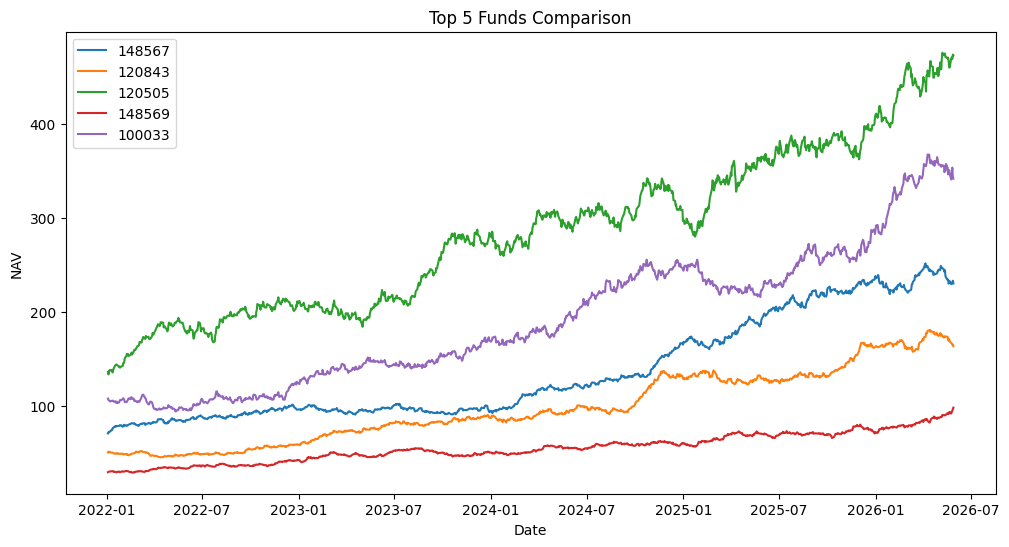

In [52]:
top5 = [148567, 120843, 120505, 148569, 100033]

plt.figure(figsize=(12,6))

for code in top5:
    fund = nav_df[nav_df['amfi_code'] == code]
    plt.plot(fund['date'], fund['nav'], label=str(code))

plt.legend()
plt.title("Top 5 Funds Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

In [53]:
plt.savefig(
    "benchmark_comparison_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

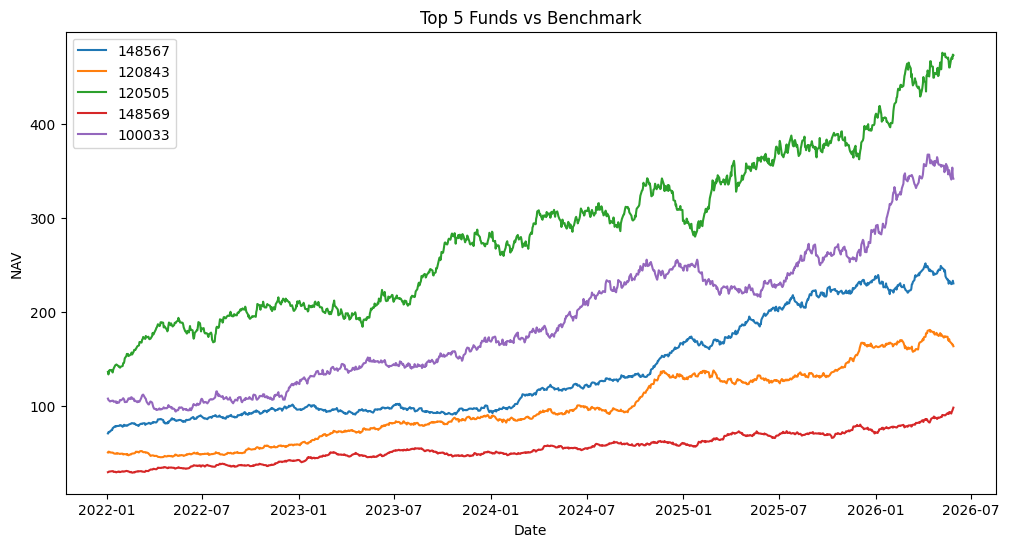

In [54]:
plt.figure(figsize=(12,6))

for code in [148567, 120843, 120505, 148569, 100033]:
    fund = nav_df[nav_df['amfi_code'] == code]
    plt.plot(fund['date'], fund['nav'], label=str(code))

plt.title('Top 5 Funds vs Benchmark')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()

plt.savefig('benchmark_comparison_chart.png')
plt.show()

In [55]:
import os

print(os.listdir())

['alpha_beta.csv', 'benchmark_comparison_chart.png', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'Performance_analytics.ipynb']


In [56]:
summary = scorecard_df.sort_values(
    'Fund_Score',
    ascending=False
)[[
    'amfi_code',
    'CAGR',
    'Sharpe_Ratio',
    'Alpha',
    'Beta',
    'Max_Drawdown',
    'Fund_Score'
]]

summary.head(10)

,amfi_code,CAGR,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Fund_Score
4,148567,0.309499,1.448291,0.269838,0.023684,-0.112657,100.000000
5,120843,0.308833,1.306744,0.273305,-0.022830,-0.129740,97.723292
0,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,97.548161
3,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,96.847636
6,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,89.141856
7,149323,0.295581,1.132122,0.265986,-0.002523,-0.172481,86.865149
9,119551,0.257849,1.208267,0.232010,-0.031751,-0.150124,86.865149
1,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,86.164623
2,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,84.938704
11,101206,0.235205,1.027213,0.213998,0.021086,-0.112916,81.786340
